****

****

****

****

## Załadowanie bibliotek


In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


## Wczytanie i czyszczenie danych

In [8]:
file_path = 'household_power_consumption.txt'
df = pd.read_csv(file_path, sep=';', na_values='?', low_memory=False)
df = df.dropna()

## Przygotowanie danych

In [9]:
features = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## K-means

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels


## GMM

In [11]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
df['GMM_Cluster'] = gmm_labels

## Wykresy

Text(0, 0.5, 'Global_reactive_power (skalowane)')

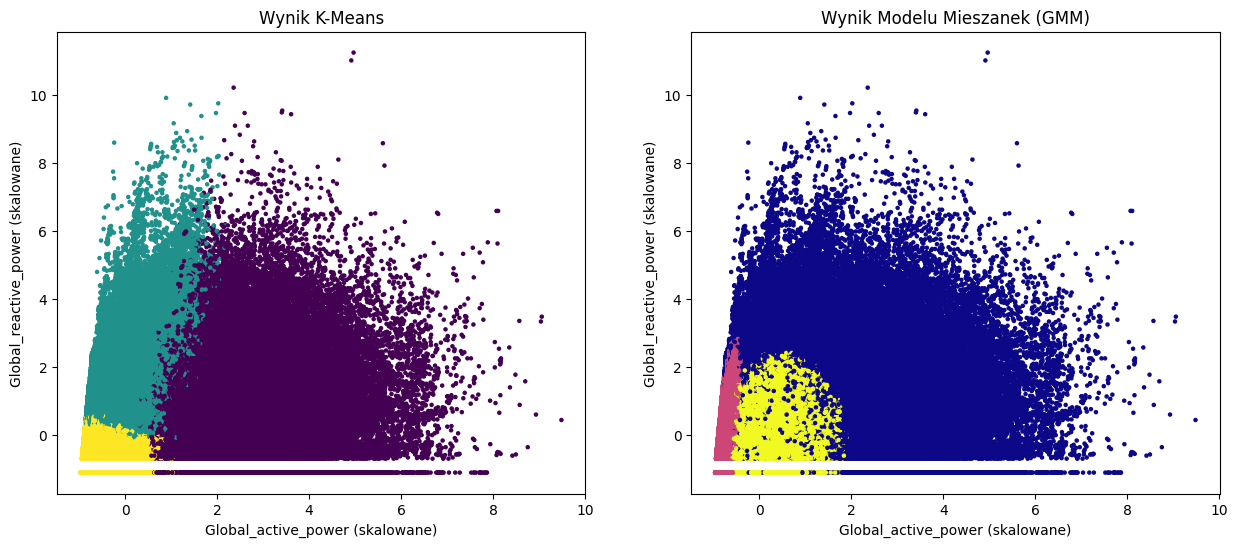

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, s=5, cmap='viridis')
ax1.set_title('Wynik K-Means')
ax1.set_xlabel('Global_active_power (skalowane)')
ax1.set_ylabel('Global_reactive_power (skalowane)')

### Wykres dla GMM

ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels, s=5, cmap='plasma')
ax2.set_title('Wynik Modelu Mieszanek (GMM)')
ax2.set_xlabel('Global_active_power (skalowane)')
ax2.set_ylabel('Global_reactive_power (skalowane)')

## Zapis wyników do CSV

In [13]:
df.to_csv('wyniki_klasteryzacji.csv', index=False)